Aperçu du dataset :
   Unnamed: 0       job_title   job_type experience_level       location  \
0           0  Data scientist  Full Time           Senior  New York City   
1           2  Data scientist  Full Time           Senior         Boston   
2           3  Data scientist  Full Time           Senior         London   
3           4  Data scientist  Full Time           Senior         Boston   
4           5  Data scientist  Full Time           Senior  New York City   

  salary_currency  salary  
0             USD  149000  
1             USD  120000  
2             USD   68000  
3             USD  120000  
4             USD  149000  

Dimensions du dataset :
(1171, 7)

Colonnes du dataset :
Index(['Unnamed: 0', 'job_title', 'job_type', 'experience_level', 'location',
       'salary_currency', 'salary'],
      dtype='object')

Valeurs manquantes par colonne :
Unnamed: 0          0
job_title           0
job_type            0
experience_level    0
location            0
salary_currency 

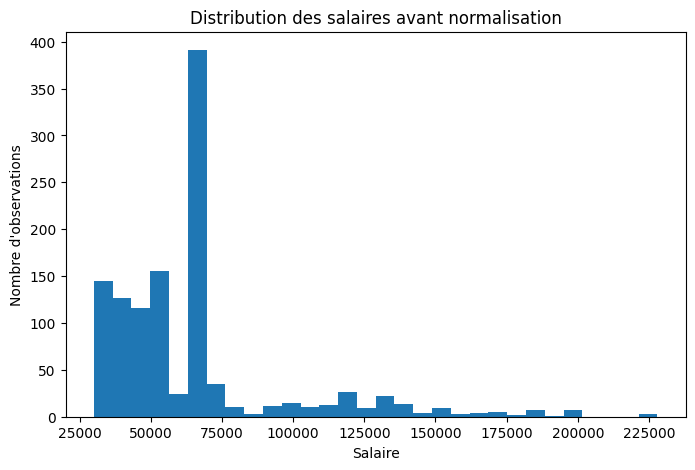

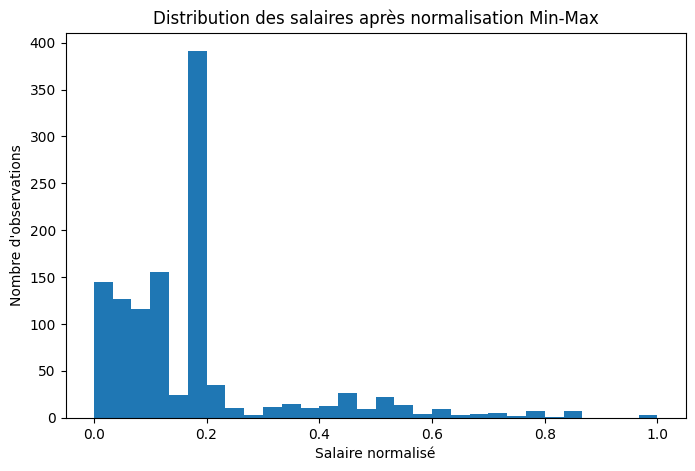


Colonnes numériques utilisées pour l'ACP :
Index(['Unnamed: 0', 'salary', 'salary_normalized'], dtype='object')

Résultat de l'ACP :
        PC1       PC2
0  3.636314 -1.493641
1  2.376053 -1.471852
2  0.116216 -1.436780
3  2.376099 -1.468762
4  3.636428 -1.485916


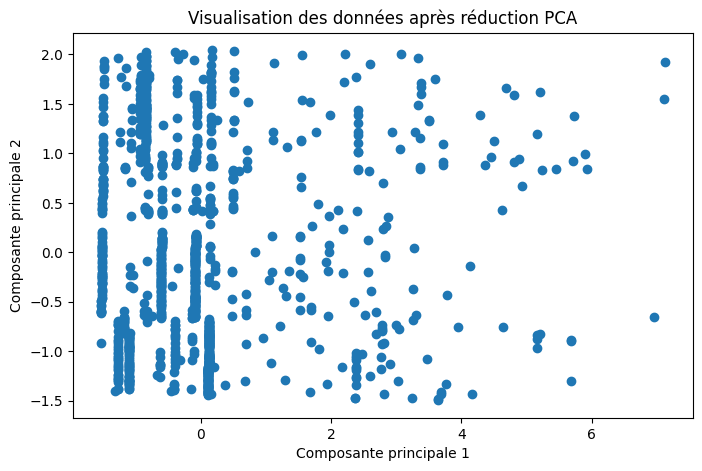


Variance expliquée par PC1 et PC2 :
[0.66674005 0.33325995]

Variance totale expliquée :
1.0

Colonne utilisée pour le niveau d'expérience : experience_level

Salaire moyen et médian par niveau d'expérience :
                  salaire_moyen  salaire_median  nombre_observations
experience_level                                                    
Entry                  36111.11         30000.0                  126
Executive              76076.92         46000.0                   13
Mid                    51786.89         51000.0                  305
Senior                 75088.03         68000.0                  727


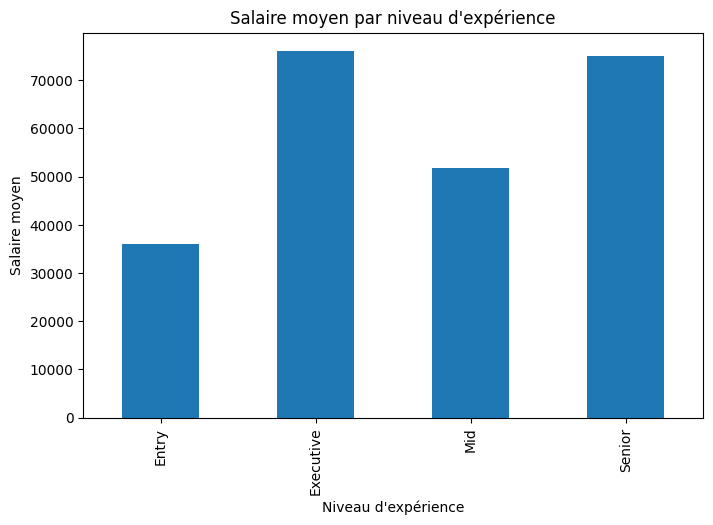

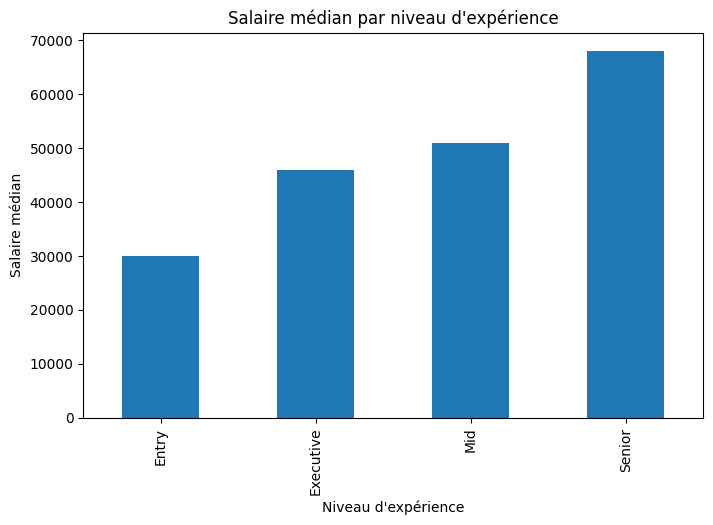


Résumé du défi quotidien
------------------------
Nombre de lignes : 1171
Nombre de colonnes : 8
Colonne salaire utilisée : salary
Colonne niveau d'expérience utilisée : experience_level

Statistiques du salaire normalisé :
count    1171.000000
mean        0.175940
std         0.164403
min         0.000000
25%         0.075758
50%         0.166667
75%         0.191919
max         1.000000
Name: salary_normalized, dtype: float64

Salaire moyen et médian par niveau d'expérience :
                  salaire_moyen  salaire_median  nombre_observations
experience_level                                                    
Entry                  36111.11         30000.0                  126
Executive              76076.92         46000.0                   13
Mid                    51786.89         51000.0                  305
Senior                 75088.03         68000.0                  727

Variance expliquée par l'ACP :
PC1 : 0.6667400539297134
PC2 : 0.3332599460702867
Total : 1.0


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.decomposition import PCA

file_path = "datascience_salaries.csv"

df = pd.read_csv(file_path)

print("Aperçu du dataset :")
print(df.head())

print("\nDimensions du dataset :")
print(df.shape)

print("\nColonnes du dataset :")
print(df.columns)

print("\nValeurs manquantes par colonne :")
print(df.isnull().sum())

if "salary_in_usd" in df.columns:
    salary_column = "salary_in_usd"
elif "salary" in df.columns:
    salary_column = "salary"
else:
    raise ValueError("Aucune colonne de salaire trouvée dans le dataset.")

print("\nColonne utilisée pour le salaire :", salary_column)


minmax_scaler = MinMaxScaler()

df["salary_normalized"] = minmax_scaler.fit_transform(df[[salary_column]])

print("\nSalaire avant et après normalisation :")
print(df[[salary_column, "salary_normalized"]].head())


plt.figure(figsize=(8, 5))
plt.hist(df[salary_column], bins=30)
plt.title("Distribution des salaires avant normalisation")
plt.xlabel("Salaire")
plt.ylabel("Nombre d'observations")
plt.show()


plt.figure(figsize=(8, 5))
plt.hist(df["salary_normalized"], bins=30)
plt.title("Distribution des salaires après normalisation Min-Max")
plt.xlabel("Salaire normalisé")
plt.ylabel("Nombre d'observations")
plt.show()


numeric_data = df.select_dtypes(include=["int64", "float64"])

numeric_data = numeric_data.fillna(numeric_data.median())

print("\nColonnes numériques utilisées pour l'ACP :")
print(numeric_data.columns)


standard_scaler = StandardScaler()

numeric_scaled = standard_scaler.fit_transform(numeric_data)


pca = PCA(n_components=2)

pca_result = pca.fit_transform(numeric_scaled)

pca_df = pd.DataFrame(
    data=pca_result,
    columns=["PC1", "PC2"]
)

df_pca = pd.concat([df, pca_df], axis=1)

print("\nRésultat de l'ACP :")
print(df_pca[["PC1", "PC2"]].head())


plt.figure(figsize=(8, 5))
plt.scatter(df_pca["PC1"], df_pca["PC2"])
plt.title("Visualisation des données après réduction PCA")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.show()

print("\nVariance expliquée par PC1 et PC2 :")
print(pca.explained_variance_ratio_)

print("\nVariance totale expliquée :")
print(pca.explained_variance_ratio_.sum())

if "experience_level" in df.columns:
    experience_column = "experience_level"
elif "niveau_d_experience" in df.columns:
    experience_column = "niveau_d_experience"
elif "niveau_d'expérience" in df.columns:
    experience_column = "niveau_d'expérience"
else:
    raise ValueError("Aucune colonne de niveau d'expérience trouvée.")

print("\nColonne utilisée pour le niveau d'expérience :", experience_column)

salary_by_experience = df.groupby(experience_column)[salary_column].agg(
    salaire_moyen="mean",
    salaire_median="median",
    nombre_observations="count"
).round(2)

print("\nSalaire moyen et médian par niveau d'expérience :")
print(salary_by_experience)


salary_by_experience["salaire_moyen"].plot(kind="bar", figsize=(8, 5))
plt.title("Salaire moyen par niveau d'expérience")
plt.xlabel("Niveau d'expérience")
plt.ylabel("Salaire moyen")
plt.show()

salary_by_experience["salaire_median"].plot(kind="bar", figsize=(8, 5))
plt.title("Salaire médian par niveau d'expérience")
plt.xlabel("Niveau d'expérience")
plt.ylabel("Salaire médian")
plt.show()

print("\nRésumé du défi quotidien")
print("------------------------")
print("Nombre de lignes :", df.shape[0])
print("Nombre de colonnes :", df.shape[1])
print("Colonne salaire utilisée :", salary_column)
print("Colonne niveau d'expérience utilisée :", experience_column)

print("\nStatistiques du salaire normalisé :")
print(df["salary_normalized"].describe())

print("\nSalaire moyen et médian par niveau d'expérience :")
print(salary_by_experience)

print("\nVariance expliquée par l'ACP :")
print("PC1 :", pca.explained_variance_ratio_[0])
print("PC2 :", pca.explained_variance_ratio_[1])
print("Total :", pca.explained_variance_ratio_.sum())